In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

if os.environ['GROQ_API_KEY']:
    print("API Key is Set!!!")
else:
    raise ValueError("API Key not loaded!!!")

API Key is Set!!!


In [2]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000016B4B07BEC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016B4B303A10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### LLM Schema **(Evaluator)**

In [3]:
from pydantic import BaseModel, Field
from typing import Literal,TypedDict

class llm_schema(BaseModel):
    funny_flag: Literal["funny", "not_funny"] = Field(...,description="Is this joke funny or not?")
    feedback: str = Field(...,description="Feedback on the joke")

In [4]:
llm_with_schema = llm.with_structured_output(llm_schema)

### Graph Schema

In [5]:
class graph_schema(TypedDict):
    topic: str
    joke: str
    funny_flag: str
    feedback: str
    max_iterations: int

### Nodes

In [6]:
from langchain_core.prompts import ChatPromptTemplate

def generate_node(state: graph_schema) -> graph_schema:
    topic = state['topic']

    if state['feedback']:
        feedback = state['feedback']
        joke = state['joke']
        response = llm.invoke(f"Please modify the following joke: {joke} according to the feedback provided. feedback: {feedback}")
    else:
        response = llm.invoke(f"Create a joke on the following topic: {topic}")

    state['joke'] = response.content
    return state

In [15]:
def evaluate_node(state: graph_schema) -> graph_schema:
    joke = state['joke']
    iterations = state['max_iterations']

    prompt = ChatPromptTemplate([
        ("system", "You are a comedy critic. Your job is to evaluate the joke and provide feedback on how to make it funny."),
        ("user","Evaluate the following joke: {joke}\n. Respond with 'funny' or 'not_funny' and provide the feedback if not_funny else make it an empty string.")
    ])

    chain = prompt | llm_with_schema

    response = chain.invoke({"joke":joke})

    state['feedback'] = response.feedback
    state['funny_flag'] = response.funny_flag
    state['max_iterations'] = iterations + 1

    return state

### Conditional Edge function

In [16]:
def check(state):

    if state["funny_flag"] == "funny":
        return "end"

    if state["max_iterations"] >= 5:
        return "end"

    return "generate_node"

### Create State Graph

In [17]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

graph.add_edge(START, "generate_node")
graph.add_edge("generate_node", "evaluate_node")
graph.add_conditional_edges("evaluate_node", check, {"generate_node": "generate_node", "end":END})


generator_evaluator_graph = graph.compile()

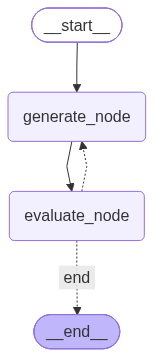

In [18]:
from IPython.display import Image, display

Image(generator_evaluator_graph.get_graph().draw_mermaid_png())

### Invoke Graph

In [19]:
generator_evaluator_graph.invoke(
    {
        "topic": "cars",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "max_iterations": 0
    }
)

{'topic': 'cars',
 'joke': 'Here\'s a modified version of the joke:\n\nWhy did the car go to the doctor after a long road trip?\n\nBecause it was feeling a little "car-sick"! But what really got the doctor\'s attention was when the car said, "I\'ve been having some exhaust-ing symptoms, and I\'m worried I\'m running on fumes!"\n\nIn this version, I\'ve added more context (a long road trip) to make the joke more relatable, and introduced a unexpected twist with the car\'s pun-filled symptoms. The additional wordplay on "exhaust-ing" and "running on fumes" adds to the humor and creates a more unexpected and playful punchline.',
 'funny_flag': 'funny',
 'feedback': '',
 'max_iterations': 2}

In [21]:
for chunk in generator_evaluator_graph.stream(
    {
            "topic": "cars",
            "joke": "",
            "funny_flag": "",
            "feedback": "",
            "max_iterations": 0
        }
):
    print(chunk)

{'generate_node': {'topic': 'cars', 'joke': 'Why did the car go to the doctor?\n\nBecause it was feeling a little "car-sick"! (get it?)', 'funny_flag': '', 'feedback': '', 'max_iterations': 0}}
{'evaluate_node': {'topic': 'cars', 'joke': 'Why did the car go to the doctor?\n\nBecause it was feeling a little "car-sick"! (get it?)', 'funny_flag': 'not_funny', 'feedback': 'The joke relies on a common pun, which may not be original or surprising enough to be humorous. Consider adding more context or wordplay to make the punchline more unexpected and clever.', 'max_iterations': 1}}
{'generate_node': {'topic': 'cars', 'joke': 'Here\'s a modified version of the joke:\n\nWhy did the car go to the doctor after its road trip?\n\nBecause it was feeling a little "car-sick"! But don\'t worry, the doctor just needed to shift its perspective and change its tune – it was just a case of exhaust-ive travel fatigue! (get it?)\n\nIn this version, I\'ve added more context to the joke by specifying that the 